In [356]:
#!pip install --trusted-host pypi.org --trusted-host files.pythonhosted.org lightgbm

In [357]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', None)

In [358]:
df = pd.read_csv("C:/Users/IEH02/Downloads/ecommerce_delivery_messy_dataset.csv")

In [359]:
# Do I need to worry about merging data or dealing with jsons (or dict) or connecting with Google Big Query

df.head()

,order_id,customer_id,order_timestamp,promised_delivery_date,actual_delivery_date,warehouse_id,carrier,shipping_method,distance_km,weather_condition,traffic_index,item_count,package_weight_kg,is_fragile,customer_lat,customer_lon,warehouse_lat,warehouse_lon,order_value_usd
0,100000,1101.0,2024-01-01 05:00:00,2024-01-02 05:00:00,2024-01-04 05:00:00,wh_a,UPS,NaN,934.523501,rain,0.109754,6,3.354961,1.0,36.956599,-103.619163,45.435284,-102.246965,23.009111
1,100001,1434.0,2024-01-02T16:00:00Z,2024-01-03 16:00:00,2024-01-05 16:00:00,WH_A,FedEx,standard,705.415816,snow,0.189653,0,5.988169,1.0,46.452682,-109.675786,49.946963,-110.350483,7.178657
2,100002,1859.0,2024-01-01 14:00:00 EST,2024-01-04 14:00:00,2024-01-06 14:00:00,WH_C,UPS,expedited,585.761536,RAIN,0.336564,8,3.732530,0.0,29.043437,-110.001968,36.176083,-83.345565,86.573165
3,100003,1269.0,2024-01-07 14:00:00 EST,2024-01-09 14:00:00,2024-01-13 14:00:00,wh_a,DHL,expedited,556.545914,sunny,0.262573,2,4.179730,0.0,43.926992,-104.352726,34.337810,-79.738579,152.743854
4,100004,1105.0,2024-01-02T07:00:00Z,2024-01-04 07:00:00,2024-01-05 07:00:00,WH_C,DHL,expedited,665.353011,Sunny,0.493971,3,6.398616,0.0,48.313814,-111.582045,40.175902,-105.335994,8.638370


In [360]:
df.isna().sum()

order_id                    0
customer_id                 6
order_timestamp             0
promised_delivery_date      0
actual_delivery_date      311
warehouse_id                0
carrier                     0
shipping_method           794
distance_km                 0
weather_condition         499
traffic_index               0
item_count                  0
package_weight_kg           0
is_fragile                988
customer_lat                0
customer_lon                0
warehouse_lat               0
warehouse_lon               0
order_value_usd             0
dtype: int64

In [361]:
df = df[~df.duplicated()]

In [362]:
df.groupby("customer_id")['order_id'].count().sort_values(ascending=False).reset_index()

,customer_id,order_id
0,1956.0,11
1,1037.0,11
2,1097.0,10
3,1316.0,9
4,1803.0,8
...,...,...
929,1305.0,1
930,1558.0,1
931,1878.0,1
932,1295.0,1


In [363]:
df['order_timestamp'] = pd.to_datetime(df['order_timestamp'].str.replace("T", " ").str.replace("Z", "").str.replace("ES", ""), errors='coerce')
df['actual_delivery_date'] = pd.to_datetime(df['actual_delivery_date'].str.replace("T", " ").str.replace("Z", "").str.replace("ES", ""),errors='coerce')
df['promised_delivery_date'] = pd.to_datetime(df['promised_delivery_date'].str.replace("T", " ").str.replace("Z", "").str.replace("ES", ""), errors='coerce')

In [364]:
df.dropna(subset=["order_timestamp"], inplace=True)
df.dropna(subset=["actual_delivery_date"], inplace=True)
df.dropna(subset=["promised_delivery_date"], inplace=True)

In [365]:
df['delta'] = df['actual_delivery_date'] - df['promised_delivery_date']
df['target'] = df['actual_delivery_date'] - df['order_timestamp']

In [366]:
df['target'] = df['target'].dt.total_seconds() / (3600 * 24)

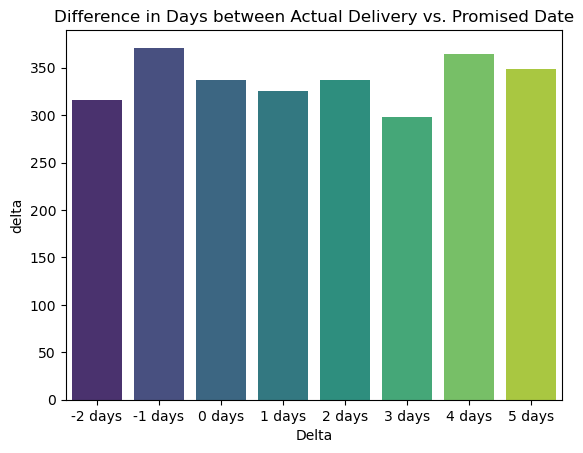

In [367]:
new_df = df['delta'].value_counts().sort_index().reset_index()
new_df['index'] = new_df['index'].astype(str)
#colors = sns.color_palette('viridis')
sns.barplot(data=new_df, x="index", y="delta", palette='viridis')
plt.xlabel("Delta")
plt.title("Difference in Days between Actual Delivery vs. Promised Date");

In [368]:
df['warehouse_id'] = df['warehouse_id'].str.replace("wh_a", "WH_A")

In [369]:
df.head()

,order_id,customer_id,order_timestamp,promised_delivery_date,actual_delivery_date,warehouse_id,carrier,shipping_method,distance_km,weather_condition,traffic_index,item_count,package_weight_kg,is_fragile,customer_lat,customer_lon,warehouse_lat,warehouse_lon,order_value_usd,delta,target
0,100000,1101.0,2024-01-01 05:00:00,2024-01-02 05:00:00,2024-01-04 05:00:00,WH_A,UPS,NaN,934.523501,rain,0.109754,6,3.354961,1.0,36.956599,-103.619163,45.435284,-102.246965,23.009111,2 days,3.0
1,100001,1434.0,2024-01-02 16:00:00,2024-01-03 16:00:00,2024-01-05 16:00:00,WH_A,FedEx,standard,705.415816,snow,0.189653,0,5.988169,1.0,46.452682,-109.675786,49.946963,-110.350483,7.178657,2 days,3.0
2,100002,1859.0,2024-01-01 14:00:00,2024-01-04 14:00:00,2024-01-06 14:00:00,WH_C,UPS,expedited,585.761536,RAIN,0.336564,8,3.732530,0.0,29.043437,-110.001968,36.176083,-83.345565,86.573165,2 days,5.0
3,100003,1269.0,2024-01-07 14:00:00,2024-01-09 14:00:00,2024-01-13 14:00:00,WH_A,DHL,expedited,556.545914,sunny,0.262573,2,4.179730,0.0,43.926992,-104.352726,34.337810,-79.738579,152.743854,4 days,6.0
4,100004,1105.0,2024-01-02 07:00:00,2024-01-04 07:00:00,2024-01-05 07:00:00,WH_C,DHL,expedited,665.353011,Sunny,0.493971,3,6.398616,0.0,48.313814,-111.582045,40.175902,-105.335994,8.638370,1 days,3.0


In [370]:
 df = df[df['distance_km'] <= 5000]

C:\Users\IEH02\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


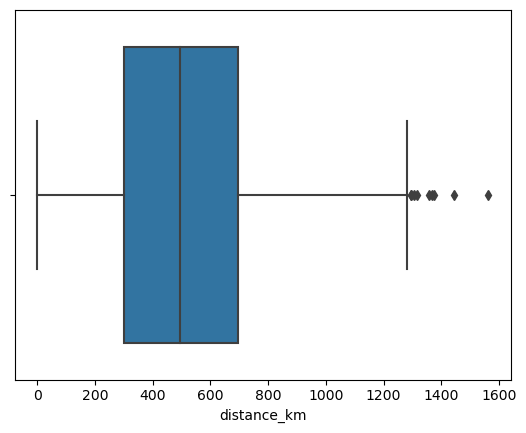

In [371]:
sns.boxplot(df['distance_km']);

In [372]:
df['weather_condition'] = np.where(df['weather_condition'] == 'RAIN', "rain", 
                              np.where(df['weather_condition'] == 'Sunny', "sunny", df['weather_condition']))



In [373]:
#df.groupby("target").agg({""})

In [374]:
#corr = df.corr(numeric_only=True)
#sns.heatmap(corr)

In [375]:
#sns.pairplot(df)

In [376]:
df.sort_values("order_timestamp", inplace=True)

In [377]:
df['dayofweek'] = df['order_timestamp'].dt.dayofweek
df['is_weekend'] = np.where(df['dayofweek'].isin([5,6]),1,0)
holiday_dates = ['2024-01-16', '2024-12-25']
df['is_holiday'] = np.where(df['order_timestamp'].dt.date.astype(str).isin(holiday_dates),1,0)

In [378]:
df = pd.get_dummies(df, columns=['shipping_method', 'warehouse_id', 'carrier', 'weather_condition'], drop_first=True)

In [379]:
df1 = df.drop(['order_id', 'customer_id', 'order_timestamp', 'promised_delivery_date', 'actual_delivery_date', 
              'delta'], axis=1)

In [380]:
df1['target'] = df1.pop("target")

In [381]:
X = df1.iloc[:,0:-1]
y = df1.iloc[:,-1]


In [382]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2687 entries, 1730 to 2108
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   distance_km               2687 non-null   float64
 1   traffic_index             2687 non-null   float64
 2   item_count                2687 non-null   int64  
 3   package_weight_kg         2687 non-null   float64
 4   is_fragile                1809 non-null   float64
 5   customer_lat              2687 non-null   float64
 6   customer_lon              2687 non-null   float64
 7   warehouse_lat             2687 non-null   float64
 8   warehouse_lon             2687 non-null   float64
 9   order_value_usd           2687 non-null   float64
 10  dayofweek                 2687 non-null   int64  
 11  is_weekend                2687 non-null   int32  
 12  is_holiday                2687 non-null   int32  
 13  shipping_method_same_day  2687 non-null   uint8  
 14  shipp

In [383]:
X_train = X.iloc[0:2500]
X_test  = X.iloc[2500:]
y_train = y.iloc[0:2500]
y_test  = y.iloc[2500:]

In [384]:
lgbm = LGBMRegressor()

lgbm.fit(X_train, y_train)
preds = lgbm.predict(X_test)
mae = mean_absolute_error(y_test, preds)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2077
[LightGBM] [Info] Number of data points in the train set: 2500, number of used features: 20
[LightGBM] [Info] Start training from score 4.543600


In [385]:
mae

2.348600004369648

In [390]:
(preds - y_test).mean()

0.10364511456537075